In [337]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
import ipycytoscape

from IPython.display import clear_output


MODEL_WITH_MASK = True


<Axes: >

2024-02-07 18:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

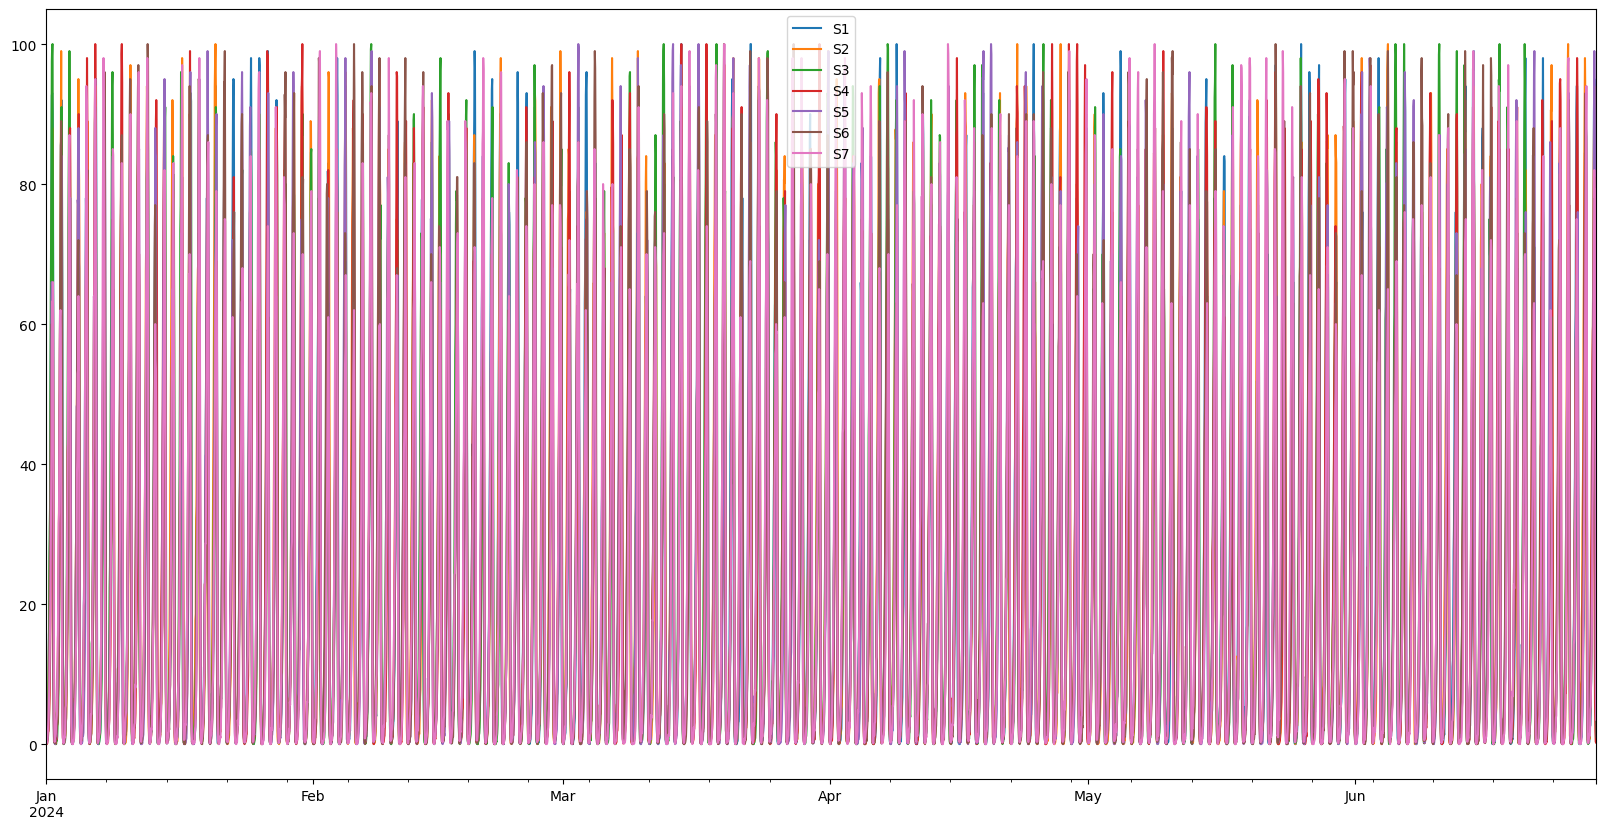

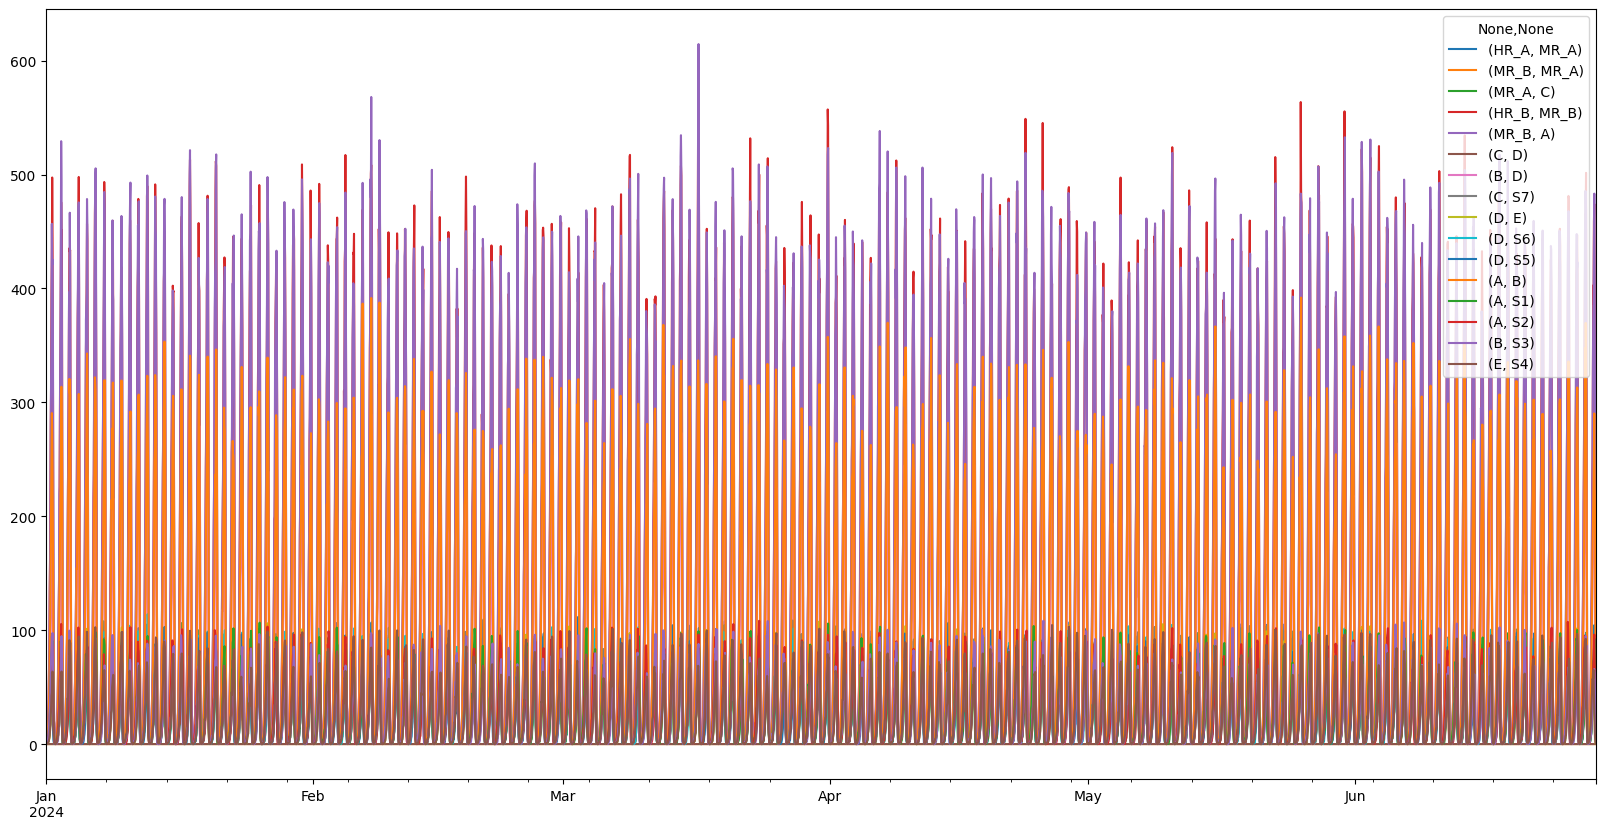

In [292]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

def visualize_flow_series(data:pd.Series):
    G_vis = nx.DiGraph()
    for k,v in data.items():
        G_vis.add_edge(k[0],k[1],weight=round(v,1))
        
    cyto = ipycytoscape.CytoscapeWidget()
    cyto.graph.add_graph_from_networkx(G_vis)

    cyto.set_style([
        {
            'selector': 'node',
            'style': {
                'label': 'data(id)',
                'background-color': '#0074D9',
                'color': 'white',
                'text-valign': 'center',
                'text-halign': 'center',
                'width': '40px',
                'height': '40px',
                'font-size': '15px',
            }
        },
        {
            'selector': 'edge',
            'style': {
                'label': 'data(weight)',  
                'width': 'mapData(weight, 0, 10, 1, 8)',
                'line-color': '#9dbaea',
                'target-arrow-shape': 'triangle',
                'curve-style': 'bezier',
                'font-size': '15px',
                'color': '#555'
            }
        }
    ])

    # 4. Configure "Gravity" (Repulsion)
    # 'nodeRepulsion' controls how much they push away from each other
    cyto.set_layout(
        name='cose',
        nodeRepulsion=400000, 
        idealEdgeLength=100,
        gravity=80
    )

    cyto.layout.width = '100%'   
    cyto.layout.height = '600px'

    return cyto


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']


DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
display(DEMANDS.plot(figsize=(20,10)))


RAW_DATA = pd.DataFrame()
for k,v in DEMANDS.iterrows():
    _flow = calculate_edge_flows(G, v.to_dict() )
    _flow.columns = [k]   
    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)

clear_output()

# SIULATING NOISE
NOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)

display(RAW_DATA.T.plot(figsize=(20,10)))

timestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]
print(timestamp)

visualize_flow_series(RAW_DATA.loc[:,timestamp])

### CREATION OF THE MASK


## PREPARATION OF DATA

In [338]:
SAMPLING = 'h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS



HR_A MR_B       MR_A        HR_B        MR_B    C  \
                          MR_A MR_A          C        MR_B           A    D   
2024-01-01 00:00:00   0.197125  0.0   0.217170    1.540952    1.563125  0.0   
2024-01-01 01:00:00   0.210156  0.0   0.211942    2.007289    1.984171  0.0   
2024-01-01 02:00:00   0.456221  0.0   0.422355    4.447700    4.715874  0.0   
2024-01-01 03:00:00   0.216363  0.0   0.210742    5.372352    4.923919  0.0   
2024-01-01 04:00:00   0.922018  0.0   0.992096   10.816365    9.824833  0.0   
...                        ...  ...        ...         ...         ...  ...   
2024-06-28 19:00:00  76.720498  0.0  77.624722  401.758466  405.806897  0.0   
2024-06-28 20:00:00  81.191250  0.0  76.534498  321.459932  289.271905  0.0   
2024-06-28 21:00:00  61.248548  0.0  55.569581  157.059485  154.603595  0.0   
2024-06-28 22:00:00  23.569740  0.0  22.391357   48.398772   47.460876  0.0   
2024-06-28 23:00:00   2.964499  0.0   3.493569    9.875184    9.387533  0.0   

                              B          C          D                        \
                              D         S7          E         S6         S5   
2024-01-01 00:00:00    0.407373   0.186601   0.168515   0.093023   0.205435   
2024-01-01 01:00:00    0.178925   0.221489   0.000000   0.089811   0.094110   
2024-01-01 02:00:00    0.588100   0.434983   0.000000   0.359269   0.294330   
2024-01-01 03:00:00    1.161870   0.217677   0.083992   0.438460   0.580021   
2024-01-01 04:00:00    2.499411   0.989985   0.462610   1.106713   0.856043   
...                         ...        ...        ...        ...        ...   
2024-06-28 19:00:00  190.226130  72.656340  18.696477  77.737666  85.995571   
2024-06-28 20:00:00  152.179611  73.923728   5.831855  61.526250  81.927703   
2024-06-28 21:00:00   74.869878  54.208410   1.819552  26.878134  47.349995   
2024-06-28 22:00:00   21.538045  24.144777   0.312309   7.770443  11.758537   
2024-06-28 23:00:00    3.655661   3.740543   0.203514   0.992853   2.756067   

                              A                                B          E  
                              B         S1         S2         S3         S4  
2024-01-01 00:00:00    0.938766   0.303693   0.276247   0.482140   0.174378  
2024-01-01 01:00:00    1.239908   0.638587   0.125731   1.004602   0.000000  
2024-01-01 02:00:00    2.234165   1.127383   1.218474   1.673026   0.000000  
2024-01-01 03:00:00    3.076188   1.136354   1.081968   1.892367   0.086455  
2024-01-01 04:00:00    6.103821   3.361644   2.007786   3.269364   0.449537  
...                         ...        ...        ...        ...        ...  
2024-06-28 19:00:00  231.957370  92.297428  76.897772  62.227022  16.780118  
2024-06-28 20:00:00  198.440881  69.410927  55.168323  41.004600   5.878097  
2024-06-28 21:00:00  103.150600  32.253784  27.708383  21.851159   1.878772  
2024-06-28 22:00:00   28.886960  11.374832   7.821528   7.880127   0.322148  
2024-06-28 23:00:00    5.183327   2.148074   1.965632   1.585397   0.200902  

[4320 rows x 16 columns]

### ATTENTION MASK

In [389]:
G_orig = nx.DiGraph()

for v in TSS.columns:
    G_orig.add_edge(v[0],v[1])

G_link = nx.line_graph(G_orig).reverse()
num_nodes = G_link.number_of_nodes()

ATT_MASK_DF = pd.DataFrame(np.ones((num_nodes, num_nodes))*float('-inf'), index=TSS.columns, columns=TSS.columns)
for line in G_link.nodes():
    ATT_MASK_DF.loc[line,line] = 0
    for neig in G_link.predecessors(line):
        ATT_MASK_DF.loc[line,neig] = 0

display(ATT_MASK_DF)




HR_A MR_B MR_A HR_B MR_B    C    B    C    D              A       \
          MR_A MR_A    C MR_B    A    D    D   S7    E   S6   S5    B   S1   
HR_A MR_A  0.0 -inf  0.0 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
MR_B MR_A -inf  0.0  0.0 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
MR_A C    -inf -inf  0.0 -inf -inf  0.0 -inf  0.0 -inf -inf -inf -inf -inf   
HR_B MR_B -inf  0.0 -inf  0.0  0.0 -inf -inf -inf -inf -inf -inf -inf -inf   
MR_B A    -inf -inf -inf -inf  0.0 -inf -inf -inf -inf -inf -inf  0.0  0.0   
C    D    -inf -inf -inf -inf -inf  0.0 -inf -inf  0.0  0.0  0.0 -inf -inf   
B    D    -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0  0.0 -inf -inf   
C    S7   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf -inf -inf   
D    E    -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf -inf   
     S6   -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf   
     S5   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf   
A    B    -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf -inf  0.0 -inf   
     S1   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0   
     S2   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
B    S3   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
E    S4   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   

                  B    E  
            S2   S3   S4  
HR_A MR_A -inf -inf -inf  
MR_B MR_A -inf -inf -inf  
MR_A C    -inf -inf -inf  
HR_B MR_B -inf -inf -inf  
MR_B A     0.0 -inf -inf  
C    D    -inf -inf -inf  
B    D    -inf -inf -inf  
C    S7   -inf -inf -inf  
D    E    -inf -inf  0.0  
     S6   -inf -inf -inf  
     S5   -inf -inf -inf  
A    B    -inf  0.0 -inf  
     S1   -inf -inf -inf  
     S2    0.0 -inf -inf  
B    S3   -inf  0.0 -inf  
E    S4   -inf -inf  0.0

## ITRANFORMER

In [358]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [359]:
ATT_MASK = torch.from_numpy(ATT_MASK_DF.values).float()
ATT_MASK

tensor([[0., -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, 0., -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf,

In [360]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 90
LR = 0.001

FREQ_H = int((TSS.index[1] - TSS.index[0]).total_seconds() / 3600)


# PREDICTION FOR A DAY
SEQ_LEN = int(1*30*(24/FREQ_H))         # 3 months
PRED_LEN = int(0.3*30*(24/FREQ_H))          # 1 month

CHANNELS =  TSS.shape[1]
TOTAL_TIME = TSS.shape[0]
D_MODEL = 256
NUM_LAYERS = 3

print(f"FREQ_H: {FREQ_H}")
print(f"TOTAL_TIME: {TOTAL_TIME}")
print(f"SEQ_LEN: {SEQ_LEN}")
print(f"PRED_LEN: {PRED_LEN}")
print(f"CHANNELS: {CHANNELS}")
print(f"D_MODEL: {D_MODEL}")
print(f"TSS shape: {TSS.shape}")
print(f"NUM layers: {NUM_LAYERS}")


FREQ_H: 1
TOTAL_TIME: 4320
SEQ_LEN: 720
PRED_LEN: 216
CHANNELS: 16
D_MODEL: 256
TSS shape: (4320, 16)
NUM layers: 3


In [361]:
from torch.utils.data import DataLoader, Dataset, Subset

class TimeSeriesDataset(Dataset):
    def __init__(self, data, lookback_len, pred_len):
        self.data = torch.FloatTensor(data)
        self.lookback_len = lookback_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.lookback_len - self.pred_len + 1

    def __getitem__(self, idx):
        # Inputs: The historical window
        x = self.data[idx : idx + self.lookback_len]
        # Targets: The future window to predict
        y = self.data[idx + self.lookback_len : idx + self.lookback_len + self.pred_len]
        return x, y

class iTransformer(nn.Module):
    """
    iTransformer: Inverted Transformer for Time Series Forecasting.
    
    Ref: iTransformer: Inverted Transformers are Effective for Time Series Forecasting
    """
    def __init__(self, num_variates, lookback_len, pred_len, d_model=512, n_heads=8, num_layers=2, dropout=0.1):
        super(iTransformer, self).__init__()
        
        self.lookback_len = lookback_len
        self.pred_len = pred_len
        self.d_model = d_model

        # 1. Embedding: Project the entire lookback window (T) to feature dimension (D)
        # In iTransformer, the MLP acts on the time dimension.
        # Input: (Batch, Num_Variates, Lookback_Len) -> Output: (Batch, Num_Variates, d_model)
        self.embedding = nn.Linear(lookback_len, d_model)
        
        # 2. Transformer Encoder: Captures multivariate correlations
        # The sequence length here is 'Num_Variates', not time steps.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Projection: Project feature dimension (D) to prediction horizon (S)
        # Input: (Batch, Num_Variates, d_model) -> Output: (Batch, Num_Variates, Pred_Len)
        self.projection = nn.Linear(d_model, pred_len)

    def forward(self, x, mask=None):
        # x shape: [Batch, Lookback_Len, Num_Variates]
        
        # Step 1: Invert dimensions to [Batch, Num_Variates, Lookback_Len]
        # This treats each variate as a "token" and the time series as the "embedding"
        x = x.permute(0, 2, 1) 
        
        # Step 2: Embedding (Linear Layer applied to the time dimension)
        # x shape becomes: [Batch, Num_Variates, d_model]
        x = self.embedding(x)
        
        # Step 3: Multivariate Interaction (Self-Attention)
        # Attention is calculated between variates.
        x = self.encoder(x, mask=mask)
        
        # Step 4: Projection to forecast horizon
        # x shape becomes: [Batch, Num_Variates, Pred_Len]
        x = self.projection(x)
        
        # Step 5: Invert back to [Batch, Pred_Len, Num_Variates] to match ground truth
        x = x.permute(0, 2, 1)
        
        return x


In [362]:
SCALER = StandardScaler()

TSS_SCALED = SCALER.fit_transform(TSS.values)

TSS_SCALED_DS = TimeSeriesDataset(TSS_SCALED, SEQ_LEN, PRED_LEN)
total_samples = len(TSS_SCALED_DS)

print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")
  

TSS_TRAIN_DS = Subset(TSS_SCALED_DS, range(0, train_size))
TSS_VAL_DS = Subset(TSS_SCALED_DS, range(train_size, total_samples))

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")


TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")

Total valid sliding windows: 3385
Train size: 2708
Val size: 677
Train size: 2708
Val size: 677
Train samples: 85 | Val samples: 22


In [363]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

MODEL

Device: cuda


iTransformer(
  (embedding): Linear(in_features=720, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (projection): Linear(in_features=256, out_features=216, bias=True)
)

In [364]:
#TRAINING
optimizer = optim.Adam(MODEL.parameters(), lr=LR)
criterion = nn.MSELoss()

In [365]:
print(f"Starting training on {device}...")
if MODEL_WITH_MASK:
    print("Using attention mask")
    attn_mask = ATT_MASK.float().to(device)
else:
    attn_mask = None
    

for epoch in range(EPOCHS):
    MODEL.train()
    train_loss = 0
    
    for batch_x, batch_y in TSS_TRAIN_DL:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
        optimizer.zero_grad()
            
        # Forward pass
        outputs = MODEL(batch_x, mask=attn_mask)
            
        # Loss calculation
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(TSS_TRAIN_DL)
        
    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in TSS_VAL_DL:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = MODEL(batch_x, mask=attn_mask)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
        
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")

Starting training on cuda...
Using attention mask
Epoch [1/90], Train Loss: 0.21260, Val Loss: 0.17048
Epoch [2/90], Train Loss: 0.15403, Val Loss: 0.16956
Epoch [3/90], Train Loss: 0.14725, Val Loss: 0.16808
Epoch [4/90], Train Loss: 0.14680, Val Loss: 0.16987
Epoch [5/90], Train Loss: 0.14331, Val Loss: 0.16797
Epoch [6/90], Train Loss: 0.14234, Val Loss: 0.16815
Epoch [7/90], Train Loss: 0.14101, Val Loss: 0.16710
Epoch [8/90], Train Loss: 0.14010, Val Loss: 0.16751
Epoch [9/90], Train Loss: 0.13909, Val Loss: 0.16810
Epoch [10/90], Train Loss: 0.13805, Val Loss: 0.16839
Epoch [11/90], Train Loss: 0.13665, Val Loss: 0.16788
Epoch [12/90], Train Loss: 0.13558, Val Loss: 0.16860
Epoch [13/90], Train Loss: 0.13481, Val Loss: 0.16929
Epoch [14/90], Train Loss: 0.13356, Val Loss: 0.17058
Epoch [15/90], Train Loss: 0.13232, Val Loss: 0.17060
Epoch [16/90], Train Loss: 0.13115, Val Loss: 0.16985
Epoch [17/90], Train Loss: 0.12997, Val Loss: 0.17222
Epoch [18/90], Train Loss: 0.12793, Val L

In [366]:
# Define your file path
SAVE_PATH = "timeseries_itranformer_model.pth"

# 1. Save the model weights
torch.save(MODEL.state_dict(), SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_itranformer_model.pth


Retrieving model from timeseries_itranformer_model.pth
torch.Size([1, 720, 16])
torch.Size([216, 16])
(720, 16)
(216, 16)
(216, 16)


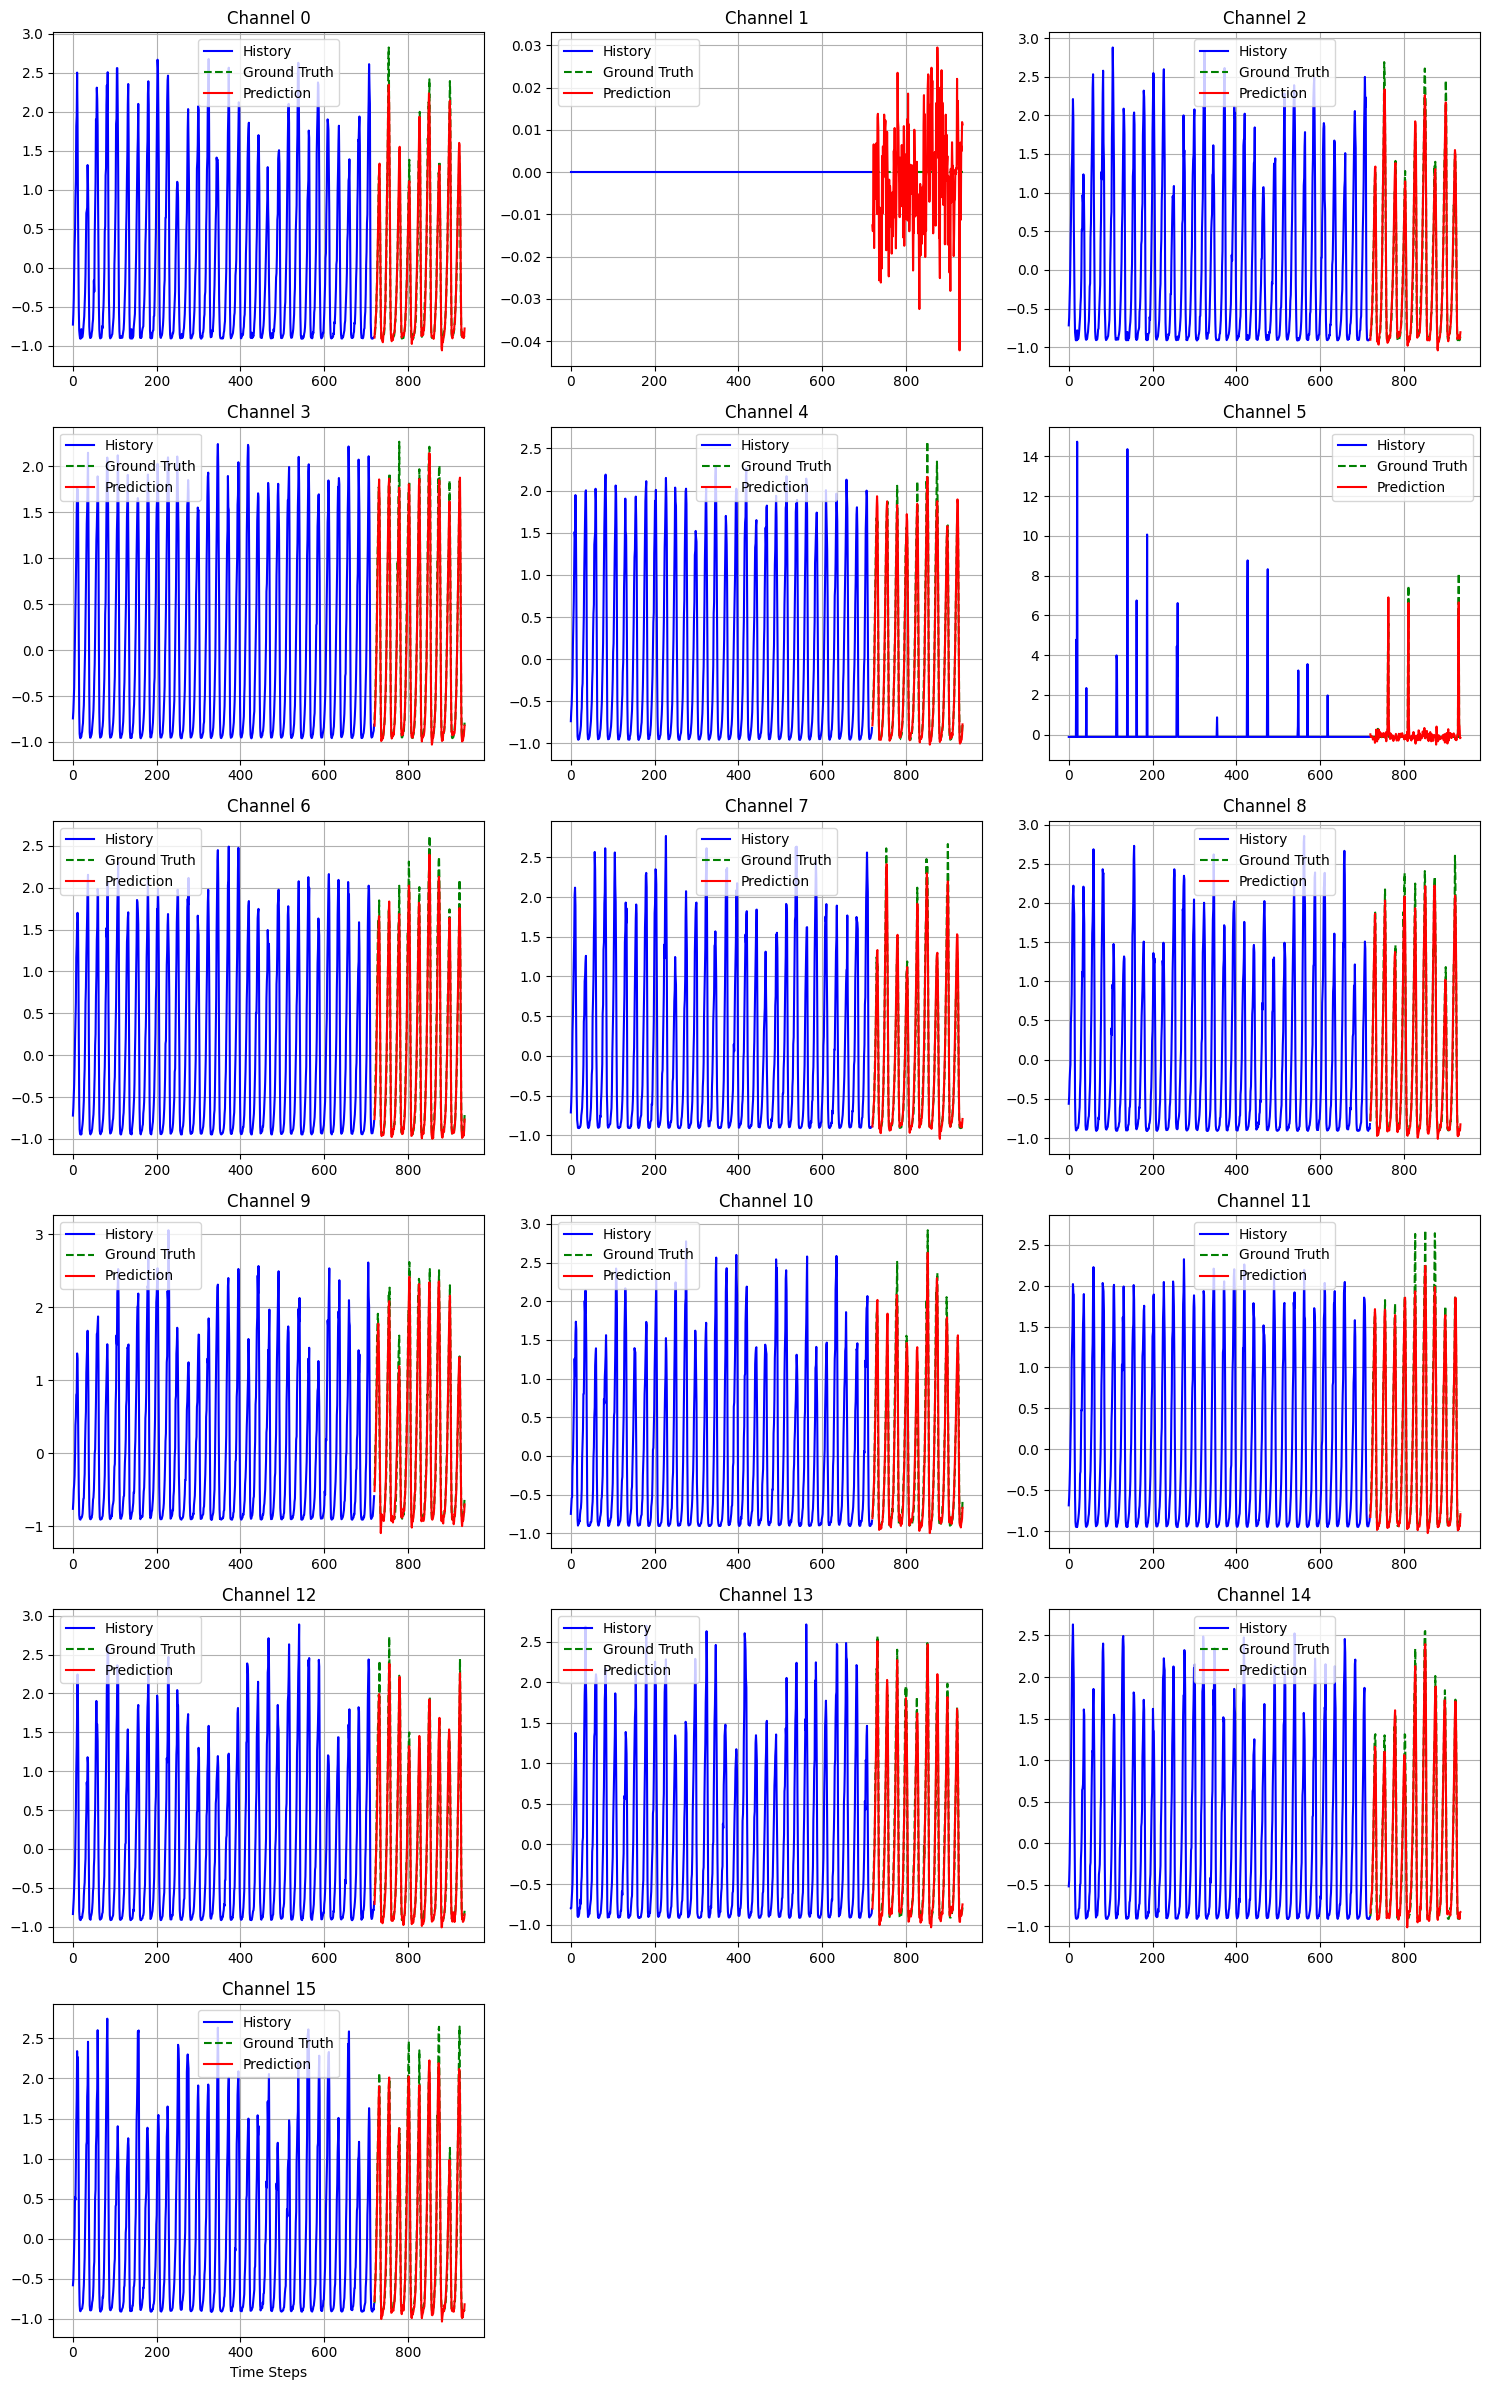

In [367]:
def plot_results(model, dataframe, seq_len, pred_len, mask=None, sample_idx=0):
    """
    Plots the Input History, Ground Truth Future, and Model Prediction for a specific sample.
    """
    dataset = TimeSeriesDataset(dataframe, seq_len, pred_len)
    input_x, true_y = dataset[sample_idx]


    # Add batch dimension for the model
    input_x_batch = input_x.unsqueeze(0)        # [1, seq_len, channels]

    print(input_x_batch.shape)
    print(true_y.shape)


    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        input_x_batch = input_x_batch.to(device)
        pred_y = model(input_x_batch, mask=mask)

    # Convert to numpy for plotting
    input_x = input_x.numpy()
    true_y = true_y.numpy()
    pred_y = pred_y.cpu().numpy().squeeze(0) # Remove batch dim
    print(input_x.shape)
    print(true_y.shape)
    print(pred_y.shape)



    # Plotting
    # --- Setup for Grid Layout ---
    num_cols = 3
    num_channels = input_x.shape[1]
    # Calculate rows needed (ceiling division)
    num_rows = (num_channels + num_cols - 1) // num_cols

    # Create the subplots
    # Note: Increased width (15) to accommodate 3 columns
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows), sharex=False)

    # Flatten the axes array (makes it 1D so we can iterate over it easily)
    # If num_channels is small, axes might not be an array, so we ensure it is iterable
    if num_channels == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    # Time axis for plotting
    x_history = np.arange(seq_len)
    x_future = np.arange(seq_len, seq_len + pred_len)


    for i in range(num_channels):
        ax = axes_flat[i]

        # Plot History
        ax.plot(x_history, input_x[:, i], label='History', color='blue')

        # Plot Ground Truth
        ax.plot(x_future, true_y[:, i], label='Ground Truth', color='green', linestyle='dashed')

        # Plot Prediction
        ax.plot(x_future, pred_y[:, i], label='Prediction', color='red')

        ax.set_title(f"Channel {i}")
        ax.legend()
        ax.grid(True)
    # --- Clean up empty subplots ---
    # If num_channels isn't a perfect multiple of 3, hide the empty axes at the end
    for i in range(num_channels, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    plt.xlabel("Time Steps")
    plt.tight_layout()
    #plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

attn_mask = ATT_MASK.float().to(device)


plot_results(MODEL, TSS_SCALED, SEQ_LEN, PRED_LEN, mask=attn_mask, sample_idx=55)

In [368]:
## PREDICTION
def predict_future_dataframe(model, dataframe, seq_len, pred_len, freq='h', scaler=None, mask=None, device='cpu'):

    model.to(device)
    model.eval()

    data_scaled= scaler.transform(dataframe.values)
    dataset = TimeSeriesDataset(data_scaled, seq_len, pred_len)
    
    last_idx = len(dataset) - 1
    input_x, true_y = dataset[last_idx]

    input_x = input_x.unsqueeze(0).to(device)         # [B, L, C]
    true_y = true_y.unsqueeze(0).to(device) # [B, L, 4]


    with torch.no_grad():
        preds = model(input_x, mask=mask)

    preds = preds.cpu().numpy().squeeze()
    preds = scaler.inverse_transform(preds)

    last_date = dataframe.index[-1]
  

    future_dates = pd.date_range(start=last_date, periods=pred_len, freq=freq)
    

    
    return  pd.DataFrame(preds, index=future_dates, columns=dataframe.columns)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

attn_mask = ATT_MASK.float().to(device)


TSS_PRED = TSS.copy()
OFFSET_PRED = TSS_PRED.index[-1]

PREDICTION_RANGE = 5
for _ in range(PREDICTION_RANGE):
    print("Predicting...")
    TSS_PRED = pd.concat([TSS_PRED, predict_future_dataframe(MODEL, TSS_PRED, SEQ_LEN, PRED_LEN, freq=f'{FREQ_H}h', scaler=SCALER, mask=attn_mask, device=device)], axis=0)


Retrieving model from timeseries_itranformer_model.pth
Predicting...
Predicting...
Predicting...
Predicting...
Predicting...


Timestamp('2024-06-28 23:00:00')

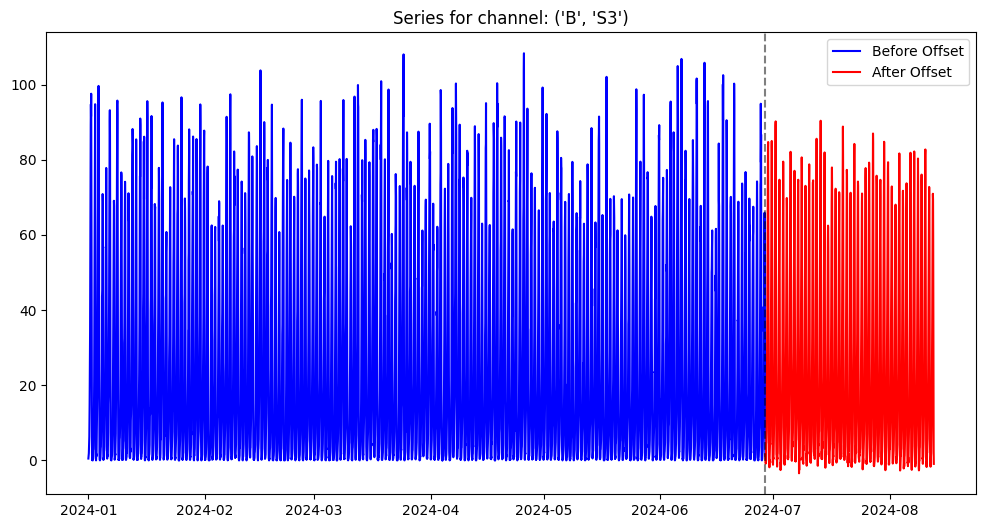

In [401]:
def plot_prediction(data:pd.Series, offset):

    plt.figure(figsize=(12, 6))
    plt.plot(data.loc[:offset], color='blue', label='Before Offset')
    plt.plot(data.loc[offset:], color='red', label='After Offset')
    plt.axvline(offset, color='black', linestyle='--', alpha=0.5)
    plt.title(f"Series for channel: {data.columns[0]}")
    plt.legend()
    plt.show()

_rand_chan = TSS_PRED.T.sample(1).index[0]
_tss_plot = TSS_PRED[[_rand_chan]]

plot_prediction(_tss_plot, OFFSET_PRED)



In [370]:
timestamp = TSS_PRED[TSS_PRED.index > OFFSET_PRED].T.sum().idxmax() 
print(timestamp)

visualize_flow_series(TSS_PRED.loc[timestamp,:])

2024-07-05 17:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

# WHAT IF



Target Channel: ('E', 'S4')
Length: 720
2024-01-17 17:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

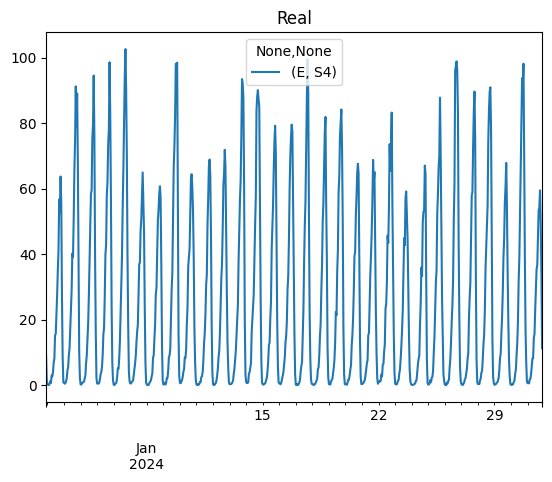

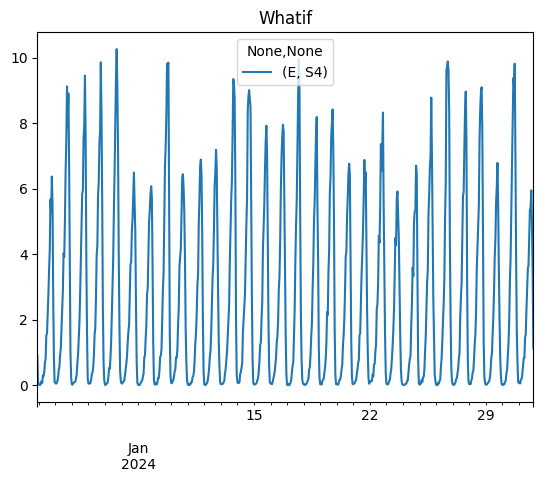

In [427]:
IDX = 22
TSS_REAL = TSS.copy()
TSS_REAL = TSS_REAL.iloc[IDX:IDX+SEQ_LEN]

TSS_WHATIF = TSS_REAL.copy()
timestamp = TSS_PRED[TSS_PRED.index > OFFSET_PRED].T.sum().idxmax() 
OFFSET_PRED = TSS_WHATIF.index[-1]

target_channel_idx = ('E', 'S4')

print(f"Target Channel: {target_channel_idx}")
print(f"Length: {len(TSS_WHATIF)}")

multiplier = 0.1

TSS_WHATIF[target_channel_idx] *= multiplier


pd.DataFrame(TSS_REAL[target_channel_idx]).plot(title="Real")
pd.DataFrame(TSS_WHATIF[target_channel_idx]).plot(title="Whatif")

timestamp = TSS_WHATIF.T.sum().idxmax() 
print(timestamp)

visualize_flow_series(TSS_WHATIF.loc[timestamp,:])

In [428]:
import re

device = 'cpu'
MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

DEMAND_LINKS = [x for x in ATT_MASK_DF.index if re.match('S\d+',x[1])]

att_mask_whatif = ATT_MASK_DF.copy()
attn_mask = torch.from_numpy(att_mask_whatif.values).float().to(device)

attn_mask 

Retrieving model from timeseries_itranformer_model.pth


tensor([[0., -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, 0., -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf, -inf, 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, -inf, -inf, -inf, -inf,

In [429]:
MODEL.eval()

data_whatif_scaled = SCALER.transform(TSS_WHATIF.values)

input_x = torch.tensor(data_whatif_scaled).float().unsqueeze(0).to(device)
print(input_x.shape)

with torch.no_grad():
    preds = MODEL(input_x, mask=attn_mask)
    preds = preds.cpu().numpy().squeeze()
    preds = SCALER.inverse_transform(preds)
    
WHATIF_PRED = pd.DataFrame(preds,  columns=TSS_WHATIF.columns)
WHATIF_PRED.index = pd.date_range(start=TSS_WHATIF.index[-1], freq=f"{FREQ_H}H", periods=len(WHATIF_PRED))

print(WHATIF_PRED.shape)

TSS_WHATIF_ALL = pd.concat([TSS_WHATIF,WHATIF_PRED])

WHATIF_PRED


torch.Size([1, 720, 16])
(216, 16)


C:\Users\valdo\AppData\Local\Temp\ipykernel_1388\435459136.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  WHATIF_PRED.index = pd.date_range(start=TSS_WHATIF.index[-1], freq=f"{FREQ_H}H", periods=len(WHATIF_PRED))


HR_A      MR_B       MR_A        HR_B        MR_B  \
                          MR_A      MR_A          C        MR_B           A   
2024-01-31 21:00:00  10.544815 -0.007305  11.800012   38.673836   44.425278   
2024-01-31 22:00:00   1.537432 -0.002567   0.601971   -2.564926   -4.888489   
2024-01-31 23:00:00  -0.433016  0.000938  -0.946795   -5.666534   -8.308655   
2024-02-01 00:00:00   0.655928  0.015948  -0.324114   -3.698746   -8.693634   
2024-02-01 01:00:00  -0.244795 -0.007219  -0.918854    3.734436   -2.475204   
...                        ...       ...        ...         ...         ...   
2024-02-09 16:00:00  79.648773 -0.005673  78.439659  410.176849  409.682251   
2024-02-09 17:00:00  94.418785  0.006739  92.851028  408.531372  411.475281   
2024-02-09 18:00:00  98.765228  0.005850  97.658569  340.188354  343.555878   
2024-02-09 19:00:00  78.803123  0.014996  78.551933  231.363098  225.178833   
2024-02-09 20:00:00  48.512627  0.009513  49.103325  123.462814  112.894287   

                            C           B          C          D             \
                            D           D         S7          E         S6   
2024-01-31 21:00:00 -0.037009   10.187973  10.608274   4.506004   5.091106   
2024-01-31 22:00:00  0.031584   -1.734161   1.297710  -1.719332  -0.633530   
2024-01-31 23:00:00 -0.010045   -2.420151  -0.420279  -1.031805   0.617889   
2024-02-01 00:00:00  0.037090   -3.590973   0.600842  -2.199705  -1.381046   
2024-02-01 01:00:00  0.066652    1.155777  -0.063042  -1.294949   0.035868   
...                       ...         ...        ...        ...        ...   
2024-02-09 16:00:00  0.020262  201.895355  81.606804  51.463478  72.495178   
2024-02-09 17:00:00  0.028712  213.097885  95.783424  59.119896  84.511078   
2024-02-09 18:00:00  0.025105  185.837830  99.475281  57.807045  80.923569   
2024-02-09 19:00:00  0.012341  130.302902  79.166252  47.799393  62.598305   
2024-02-09 20:00:00  0.006365   67.119255  48.310181  28.817972  35.747807   

                                         A                                B  \
                            S5           B         S1         S2         S3   
2024-01-31 21:00:00   4.442862   23.914429   9.243177   6.576807  11.044954   
2024-01-31 22:00:00  -1.243727    0.250710  -0.567839  -1.834747  -1.627007   
2024-01-31 23:00:00  -0.629663   -5.431847  -1.041748  -1.920387  -2.205984   
2024-02-01 00:00:00   0.456867   -5.573738  -0.102621  -0.039948  -0.282391   
2024-02-01 01:00:00  -0.084009    2.245186  -0.988831  -0.213619  -1.077959   
...                        ...         ...        ...        ...        ...   
2024-02-09 16:00:00  75.145042  282.643494  65.522720  71.374710  67.425697   
2024-02-09 17:00:00  71.418945  280.580902  66.133896  79.042801  63.860054   
2024-02-09 18:00:00  51.475826  234.306122  55.877693  73.039536  51.307194   
2024-02-09 19:00:00  30.438023  160.740662  36.294197  53.929440  32.283100   
2024-02-09 20:00:00  14.230350   82.396164  17.862370  27.836447  16.503986   

                             E  
                            S4  
2024-01-31 21:00:00  23.321630  
2024-01-31 22:00:00  22.096447  
2024-01-31 23:00:00  27.014450  
2024-02-01 00:00:00  28.853260  
2024-02-01 01:00:00  17.605091  
...                        ...  
2024-02-09 16:00:00  30.635590  
2024-02-09 17:00:00  24.431168  
2024-02-09 18:00:00  22.892262  
2024-02-09 19:00:00  22.782442  
2024-02-09 20:00:00  17.577585  

[216 rows x 16 columns]

In [431]:
TSS_WHATIF_ALL[[target_channel_idx]]

,E
,S4
2024-01-01 22:00:00,0.897839
2024-01-01 23:00:00,0.117561
2024-01-02 00:00:00,0.017052
2024-01-02 01:00:00,0.009475
2024-01-02 02:00:00,0.000000
...,...
2024-02-09 16:00:00,30.635590
2024-02-09 17:00:00,24.431168
2024-02-09 18:00:00,22.892262


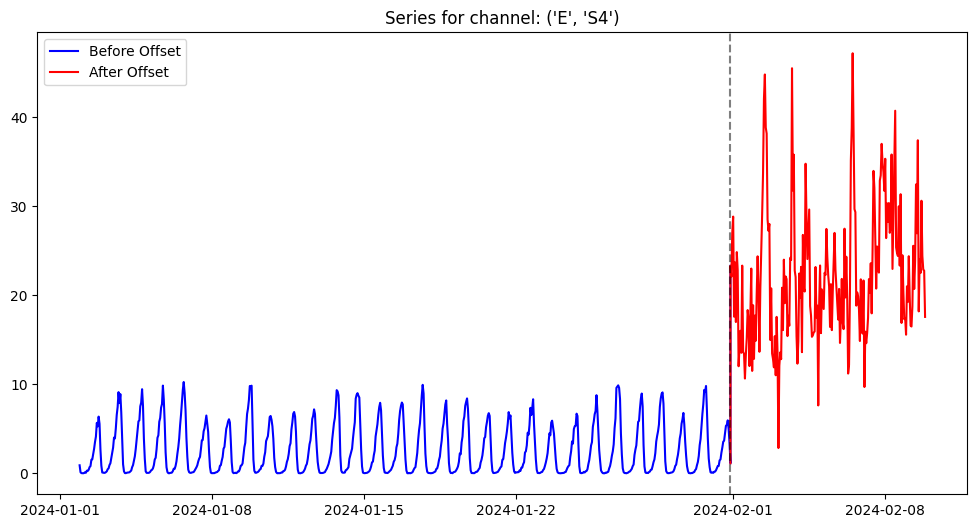

In [433]:

_tss_plot = TSS_WHATIF_ALL[[target_channel_idx]]
plot_prediction(_tss_plot, TSS_WHATIF.index[-1])

In [434]:
timestamp = WHATIF_PRED.sum(axis=1).idxmax()
print(timestamp)

visualize_flow_series(WHATIF_PRED.loc[timestamp,:])

2024-02-07 17:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

HR_A MR_B MR_A HR_B MR_B    C    B    C    D              A       \
          MR_A MR_A    C MR_B    A    D    D   S7    E   S6   S5    B   S1   
HR_A MR_A  0.4  0.0  0.6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B MR_A  0.0  0.5  0.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A C     0.0  0.0  0.6  0.0  0.0  0.1  0.0  0.3  0.0  0.0  0.0  0.0  0.0   
HR_B MR_B  0.0  0.2  0.0  0.4  0.4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B A     0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.2   
C    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.3  0.5  0.0  0.0   
B    D     0.0  0.0  0.0  0.0  0.0  0.0  0.1  0.0  0.1  0.7  0.0  0.0  0.0   
C    S7    0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
D    E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.6  0.0  0.0  0.0  0.0   
     S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0   
     S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0   
A    B     0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.0  0.0  0.0  0.0  0.2  0.0   
     S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0   
     S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B    S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
E    S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                  B    E  
            S2   S3   S4  
HR_A MR_A  0.0  0.0  0.0  
MR_B MR_A  0.0  0.0  0.0  
MR_A C     0.0  0.0  0.0  
HR_B MR_B  0.0  0.0  0.0  
MR_B A     0.4  0.0  0.0  
C    D     0.0  0.0  0.0  
B    D     0.0  0.0  0.0  
C    S7    0.0  0.0  0.0  
D    E     0.0  0.0  0.4  
     S6    0.0  0.0  0.0  
     S5    0.0  0.0  0.0  
A    B     0.0  0.3  0.0  
     S1    0.0  0.0  0.0  
     S2    1.0  0.0  0.0  
B    S3    0.0  1.0  0.0  
E    S4    0.0  0.0  1.0

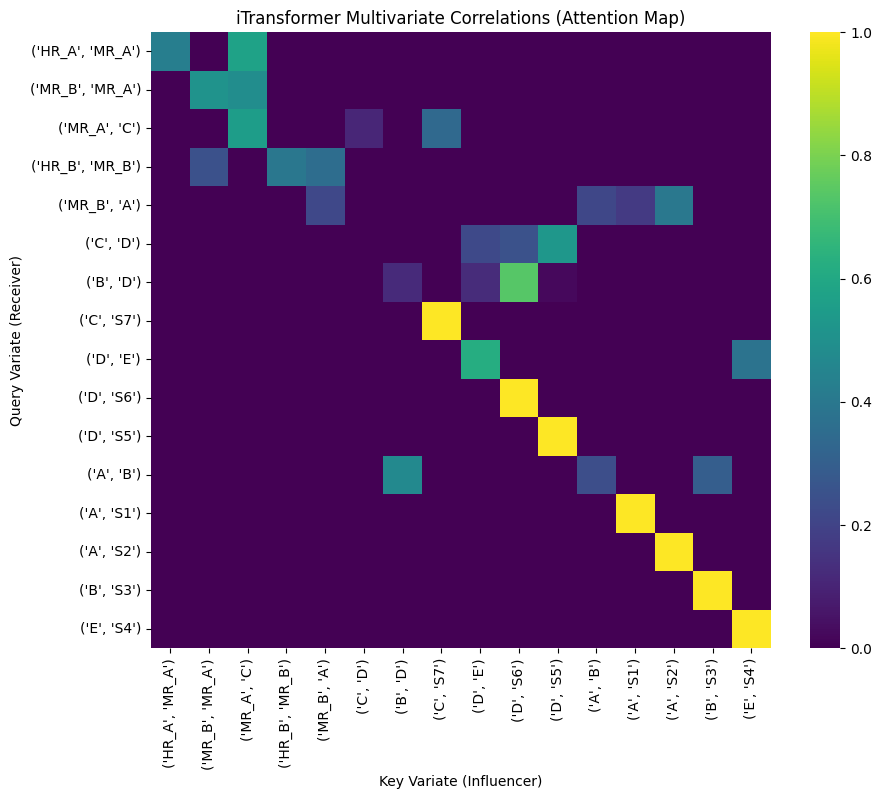

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def get_attention_matrix(model, scaler, raw_input, layer_idx=0, mask=None, device='cpu'):
    """
    Extracts the attention weights between variates from a specific encoder layer.
    
    Args:
        model: Trained iTransformer model.
        scaler: The scaler used during training.
        raw_input: Numpy array of shape (Lookback, Num_Variates).
        layer_idx: Which Transformer layer to inspect (0 is the first layer).
        
    Returns:
        attn_weights: Numpy array of shape (Num_Variates, Num_Variates).
    """
    model.eval()
    
    input_scaled = scaler.transform(raw_input)
    tensor_x = torch.tensor(input_scaled).float().unsqueeze(0).to(device) # Shape: (1, Lookback, N)

    if mask is not None:
        mask = mask.to(device)

    with torch.no_grad():

        x = tensor_x.permute(0, 2, 1)
        x_embedded = model.embedding(x)
        

        encoder_layer = model.encoder.layers[layer_idx]
        self_attn = encoder_layer.self_attn
        

        attn_output, attn_weights = self_attn(
            x_embedded, 
            x_embedded, 
            x_embedded, 
            attn_mask=mask,
            need_weights=True,
            average_attn_weights=True
        )
        
        return attn_weights[0].cpu().numpy()

def plot_attention_heatmap(attn_matrix, column_names=None):
    plt.figure(figsize=(10, 8))
    
    # Create labels if not provided
    if column_names is None:
        column_names = [f"Ch{i}" for i in range(attn_matrix.shape[0])]
        
    sns.heatmap(
        attn_matrix, 
        xticklabels=column_names, 
        yticklabels=column_names, 
        cmap="viridis", 
        annot=False # Set to True if you want to see the exact numbers
    )
    
    plt.title("iTransformer Multivariate Correlations (Attention Map)")
    plt.xlabel("Key Variate (Influencer)")
    plt.ylabel("Query Variate (Receiver)")
    plt.show()



attn_weights = get_attention_matrix(MODEL, SCALER, TSS_WHATIF, mask=attn_mask, layer_idx=2)

ATTENTION_DF = pd.DataFrame(attn_weights, index=ORIG_COLS, columns=ORIG_COLS)
display(ATTENTION_DF.round(1))

plot_attention_heatmap(attn_weights, column_names=TSS_WHATIF.columns)


